<a href="https://colab.research.google.com/github/SHANLYKS47/Formula-1/blob/main/f1_laptime_colab_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# F1 Lap Time Prediction Project
Research Question

To what extent can machine learning predict Formula 1 lap time under clean race conditions, and how can explainable AI methods (SHAP and LIME) be used to interpret these predictions?

Data used :
- race-session loading for **2022, 2023, 2024**

In [85]:
# 1. Install packages
!pip -q install fastf1 lightgbm xgboost shap lime pyarrow

In [86]:
# Cell 2 — Import libraries
import os
import time
import json
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import fastf1

from google.colab import drive

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [87]:
# 3. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
# 4. Create project directories

PROJECT_ROOT = "/content/drive/MyDrive/Fast_F1_PROJECT21"
CACHE_DIR = os.path.join(PROJECT_ROOT, "cache_fastf1")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
FIG_DIR = os.path.join(PROJECT_ROOT, "figures")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")

for path in [PROJECT_ROOT, CACHE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, MODEL_DIR, FIG_DIR, RESULTS_DIR]:
    os.makedirs(path, exist_ok=True)

print("Created project folders under:", PROJECT_ROOT)

Created project folders under: /content/drive/MyDrive/Fast_F1_PROJECT21


In [89]:
# 5. Enable FastF1 cache

fastf1.Cache.enable_cache(CACHE_DIR)
print("FastF1 cache enabled:", CACHE_DIR)

FastF1 cache enabled: /content/drive/MyDrive/Fast_F1_PROJECT21/cache_fastf1


In [90]:
# Cell 6 — Rate limit and retry helper
CALLS_PER_HOUR = 500
SECONDS_PER_CALL = 3600 / CALLS_PER_HOUR
_last_call_time = 0.0

def wait_for_rate_limit():
    global _last_call_time
    now = time.time()
    elapsed = now - _last_call_time
    if elapsed < SECONDS_PER_CALL:
        time.sleep(SECONDS_PER_CALL - elapsed)
    _last_call_time = time.time()

def retry_api_call(func, *args, max_retries=4, base_wait=5, **kwargs):
    for attempt in range(1, max_retries + 1):
        try:
            wait_for_rate_limit()
            return func(*args, **kwargs)
        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")
            if attempt == max_retries:
                raise
            sleep_time = base_wait * (2 ** (attempt - 1)) + random.uniform(0, 1.5)
            print(f"Retrying in {sleep_time:.1f} seconds...")
            time.sleep(sleep_time)

## Load race-only data and save local copies

This loads only **race sessions** (`'R'`) for 2022–2024, which matches your project scope.

In [91]:
#Cell 7 — Load race-only data and save event schedule + parquet files
seasons = [2022, 2023, 2024]
all_laps = []
all_schedules = []

for year in seasons:
    print(f"\nLoading season {year}")
    schedule = retry_api_call(fastf1.get_event_schedule, year, include_testing=False).copy()
    schedule["Season"] = year
    all_schedules.append(schedule)

    schedule_save_path = os.path.join(RAW_DIR, f"{year}_event_schedule.csv")
    schedule.to_csv(schedule_save_path, index=False)

    for _, event in schedule.iterrows():
        round_number = int(event["RoundNumber"])
        race_name = event["EventName"]
        file_name = f"{year}_round_{round_number:02d}_race_laps.parquet"
        save_path = os.path.join(RAW_DIR, file_name)

        if os.path.exists(save_path):
            print(f"Using saved file: {file_name}")
            laps = pd.read_parquet(save_path)
            all_laps.append(laps)
            continue

        try:
            print(f"Downloading {year} Round {round_number}: {race_name}")
            session = retry_api_call(fastf1.get_session, year, round_number, "R")
            retry_api_call(
                session.load,
                laps=True,
                telemetry=False,
                weather=False,
                messages=False
            )

            laps = session.laps.copy()
            laps["Season"] = year
            laps["RoundNumber"] = round_number
            laps["Race"] = race_name
            laps["Circuit"] = event["Location"] if "Location" in event.index else race_name

            laps.to_parquet(save_path, index=False)
            all_laps.append(laps)

        except Exception as e:
            print(f"Skipping {race_name}: {e}")

df = pd.concat(all_laps, ignore_index=True)
schedule_df = pd.concat(all_schedules, ignore_index=True)

schedule_df.to_csv(os.path.join(RAW_DIR, "all_event_schedules.csv"), index=False)

print("Raw dataset shape:", df.shape)
display(schedule_df[["Season", "RoundNumber", "EventName", "Location"]].head())


Loading season 2022
Using saved file: 2022_round_01_race_laps.parquet
Using saved file: 2022_round_02_race_laps.parquet
Using saved file: 2022_round_03_race_laps.parquet
Using saved file: 2022_round_04_race_laps.parquet
Using saved file: 2022_round_05_race_laps.parquet
Using saved file: 2022_round_06_race_laps.parquet
Using saved file: 2022_round_07_race_laps.parquet
Using saved file: 2022_round_08_race_laps.parquet
Using saved file: 2022_round_09_race_laps.parquet
Using saved file: 2022_round_10_race_laps.parquet
Using saved file: 2022_round_11_race_laps.parquet
Using saved file: 2022_round_12_race_laps.parquet
Using saved file: 2022_round_13_race_laps.parquet
Using saved file: 2022_round_14_race_laps.parquet
Using saved file: 2022_round_15_race_laps.parquet
Using saved file: 2022_round_16_race_laps.parquet
Using saved file: 2022_round_17_race_laps.parquet
Using saved file: 2022_round_18_race_laps.parquet
Using saved file: 2022_round_19_race_laps.parquet
Using saved file: 2022_round_

,Season,RoundNumber,EventName,Location
0,2022,1,Bahrain Grand Prix,Sakhir
1,2022,2,Saudi Arabian Grand Prix,Jeddah
2,2022,3,Australian Grand Prix,Melbourne
3,2022,4,Emilia Romagna Grand Prix,Imola
4,2022,5,Miami Grand Prix,Miami


In [92]:
# Cell 8 — Basic inspection
print("Raw dataset shape:", df.shape)
print("Number of columns:", len(df.columns))
print("Sample columns:", df.columns.tolist()[:20])
display(df.head())

Raw dataset shape: (74605, 35)
Number of columns: 35
Sample columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,Sector3Time,Sector1SessionTime,Sector2SessionTime,Sector3SessionTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,Season,RoundNumber,Race,Circuit
0,0 days 01:04:15.340000,VER,1,0 days 00:01:40.236000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.325000,0 days 00:00:24.389000,NaT,0 days 01:03:51.046000,0 days 01:04:15.427000,230.0,254.0,274.0,250.0,False,SOFT,4.0,False,Red Bull Racing,0 days 01:02:34.872000,NaT,1,2.0,None,,False,False,2022,1,Bahrain Grand Prix,Sakhir
1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaT,NaT,0 days 00:00:31.285000,0 days 00:00:42.269000,0 days 00:00:24.326000,0 days 01:04:46.662000,0 days 01:05:28.931000,0 days 01:05:53.257000,230.0,252.0,276.0,296.0,True,SOFT,5.0,False,Red Bull Racing,0 days 01:04:15.340000,NaT,1,2.0,None,,False,True,2022,1,Bahrain Grand Prix,Sakhir
2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaT,NaT,0 days 00:00:31.499000,0 days 00:00:42.474000,0 days 00:00:24.384000,0 days 01:06:24.756000,0 days 01:07:07.230000,0 days 01:07:31.614000,229.0,254.0,276.0,294.0,False,SOFT,6.0,False,Red Bull Racing,0 days 01:05:53.220000,NaT,1,2.0,None,,False,True,2022,1,Bahrain Grand Prix,Sakhir
3,0 days 01:09:10.143000,VER,1,0 days 00:01:38.566000,4.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.674000,0 days 00:00:24.550000,0 days 01:08:02.956000,0 days 01:08:45.630000,0 days 01:09:10.180000,231.0,250.0,276.0,297.0,False,SOFT,7.0,False,Red Bull Racing,0 days 01:07:31.577000,NaT,1,2.0,None,,False,True,2022,1,Bahrain Grand Prix,Sakhir
4,0 days 01:10:49.020000,VER,1,0 days 00:01:38.877000,5.0,1.0,NaT,NaT,0 days 00:00:31.498000,0 days 00:00:42.854000,0 days 00:00:24.525000,0 days 01:09:41.678000,0 days 01:10:24.532000,0 days 01:10:49.057000,229.0,256.0,276.0,293.0,False,SOFT,8.0,False,Red Bull Racing,0 days 01:09:10.143000,NaT,1,2.0,None,,False,True,2022,1,Bahrain Grand Prix,Sakhir


## Clean-lap filtering

This keeps only race laps that are closer to normal competitive pace:
- remove lap 1
- remove pit in/out laps
- keep dry compounds only
- remove missing lap times
- remove very slow outliers within each driver-race group

Track-status handling is not perfectly standardized across all situations.

In [93]:
# Cell 9 — Clean race laps and create target

df = df.copy()

# Remove missing lap times
df = df[df["LapTime"].notna()].copy()
df["LapTimeSeconds"] = df["LapTime"].dt.total_seconds()

# Remove first lap
df = df[df["LapNumber"] > 1].copy()

# Remove pit-in / pit-out laps
df = df[df["PitInTime"].isna()].copy()
df = df[df["PitOutTime"].isna()].copy()

# Keep only dry tyre laps
df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])].copy()

# Remove Safety Car / Virtual Safety Car affected laps
# In FastF1 track status strings, code "4" is commonly used for Safety Car
# and code "5" for Virtual Safety Car in this project setup.
# remove laps where either appears in TrackStatus.
if "TrackStatus" in df.columns:
    track_status_str = df["TrackStatus"].astype(str)
    sc_mask = track_status_str.str.contains("4", regex=False, na=False)
    vsc_mask = track_status_str.str.contains("5", regex=False, na=False)
    df = df[~(sc_mask | vsc_mask)].copy()

# Remove extreme slow laps within driver-race groups
group_cols = ["Season", "RoundNumber", "Driver"]
group_median = df.groupby(group_cols)["LapTimeSeconds"].transform("median")
group_std = df.groupby(group_cols)["LapTimeSeconds"].transform("std").fillna(0)

df = df[df["LapTimeSeconds"] < (group_median + 2 * group_std)].copy()

print("Cleaned dataset shape:", df.shape)
display(df[["Season", "RoundNumber", "Driver", "LapNumber", "LapTimeSeconds"]].head())

Cleaned dataset shape: (59276, 36)


,Season,RoundNumber,Driver,LapNumber,LapTimeSeconds
1,2022,1,VER,2.0,97.880
2,2022,1,VER,3.0,98.357
3,2022,1,VER,4.0,98.566
4,2022,1,VER,5.0,98.877
5,2022,1,VER,6.0,98.940


## Feature engineering

The most important rule is:
> only use information known **before** the lap starts

So `PreviousLapTime` is created with `shift(1)`.

In [94]:
# Cell 10 — Feature engineering
df = df.sort_values(["Season", "RoundNumber", "Driver", "LapNumber"]).copy()

# Dynamic prior-lap signal
df["PreviousLapTime"] = (
    df.groupby(["Season", "RoundNumber", "Driver"])["LapTimeSeconds"]
      .shift(1)
)

# Simple nonlinear tyre feature
df["TyreLife_sq"] = df["TyreLife"] ** 2

# Clean numeric issues
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Feature engineering complete.")

Feature engineering complete.


In [95]:
# Cell 11 — Basic summary
print("Dataset shape:", df.shape)
print("\nTop missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

Dataset shape: (59276, 38)

Top missing values:
PitInTime             59276
PitOutTime            59276
LapStartDate          59276
Deleted               59276
PreviousLapTime        1267
Sector1SessionTime      152
TyreLife_sq             150
TyreLife                150
Sector2Time               1
Sector2SessionTime        1
Sector1Time               1
Time                      0
Driver                    0
DriverNumber              0
Stint                     0
dtype: int64


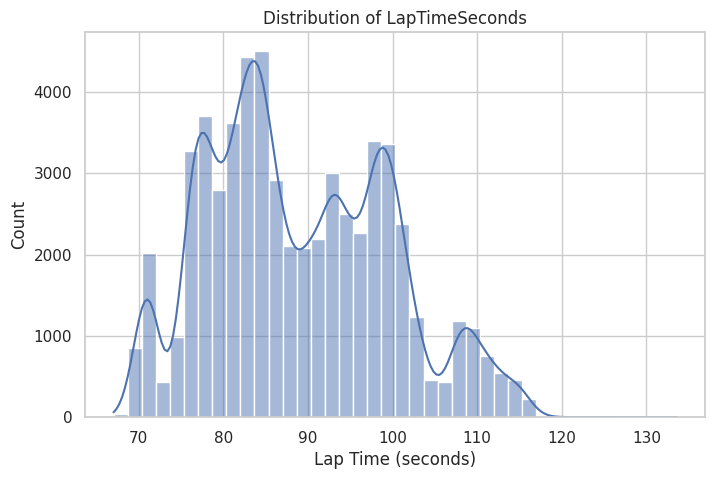

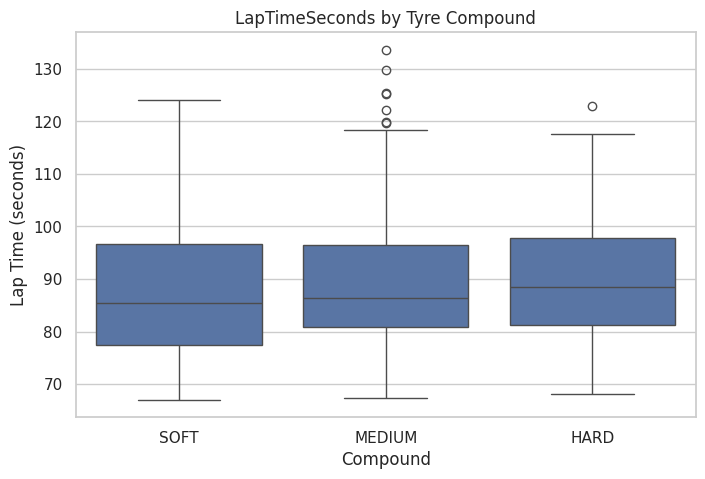

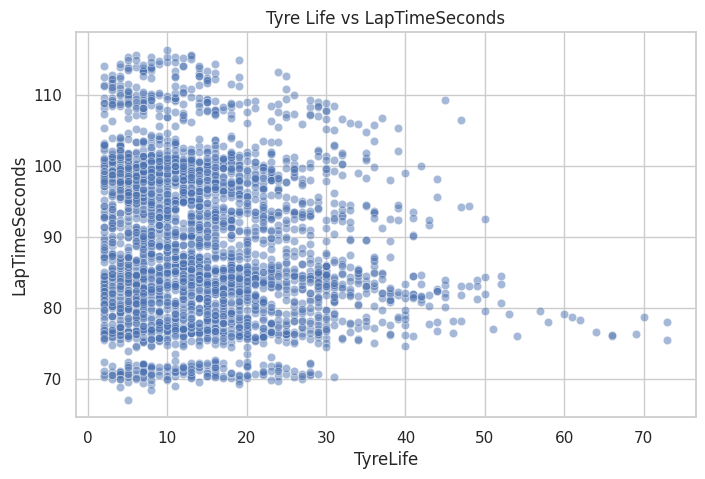

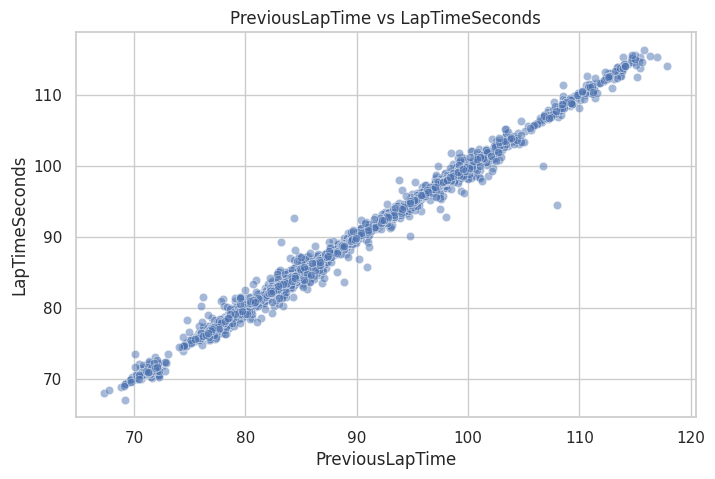

In [96]:
# Cell 12 — EDA plots
eda_df = df.dropna(subset=["LapTimeSeconds"]).copy()
sample_df = eda_df.sample(min(3000, len(eda_df)), random_state=42)

plt.figure(figsize=(8,5))
sns.histplot(eda_df["LapTimeSeconds"], bins=40, kde=True)
plt.title("Distribution of LapTimeSeconds")
plt.xlabel("Lap Time (seconds)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=eda_df, x="Compound", y="LapTimeSeconds")
plt.title("LapTimeSeconds by Tyre Compound")
plt.xlabel("Compound")
plt.ylabel("Lap Time (seconds)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=sample_df, x="TyreLife", y="LapTimeSeconds", alpha=0.5)
plt.title("Tyre Life vs LapTimeSeconds")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=sample_df.dropna(subset=["PreviousLapTime"]),
    x="PreviousLapTime",
    y="LapTimeSeconds",
    alpha=0.5
)
plt.title("PreviousLapTime vs LapTimeSeconds")
plt.show()

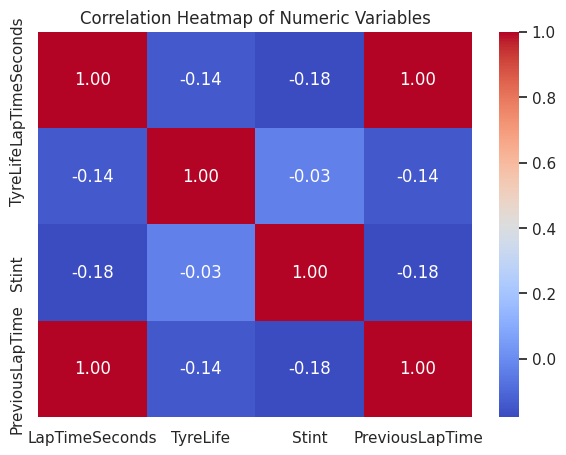

In [97]:
# Cell 13 — Correlation heatmap
numeric_cols = [c for c in ["LapTimeSeconds", "TyreLife", "Stint", "PreviousLapTime"] if c in df.columns]
corr = df[numeric_cols].dropna().corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

## Train / validation / test split

- **Train:** 2022 + 2023 races
- **Validation:** first 12 races of 2024
- **Test:** last 12 races of 2024

In [98]:
# Cell 14 — Train / validation / test split
train_df_base = df[df["Season"].isin([2022, 2023])].copy()

df_2024 = df[df["Season"] == 2024].copy()
val_df_base = df_2024[df_2024["RoundNumber"] <= 12].copy()
test_df_base = df_2024[df_2024["RoundNumber"] > 12].copy()

print("Train shape:", train_df_base.shape)
print("Validation shape:", val_df_base.shape)
print("Test shape:", test_df_base.shape)

Train shape: (38009, 38)
Validation shape: (10791, 38)
Test shape: (10476, 38)


In [99]:
# Cell 15 — Add historical baseline features
driver_baseline = (
    train_df_base.groupby("Driver")["LapTimeSeconds"]
    .mean()
    .rename("DriverAvgLap")
)

circuit_baseline = (
    train_df_base.groupby("Circuit")["LapTimeSeconds"]
    .mean()
    .rename("CircuitAvgLap")
)

team_baseline = (
    train_df_base.groupby("Team")["LapTimeSeconds"]
    .mean()
    .rename("TeamAvgLap")
)

def add_baselines(input_df):
    out = input_df.copy()
    out = out.merge(driver_baseline, on="Driver", how="left")
    out = out.merge(circuit_baseline, on="Circuit", how="left")
    out = out.merge(team_baseline, on="Team", how="left")
    return out

train_df_base = add_baselines(train_df_base)
val_df_base = add_baselines(val_df_base)
test_df_base = add_baselines(test_df_base)

train_mean_lap = train_df_base["LapTimeSeconds"].mean()

for col in ["DriverAvgLap", "CircuitAvgLap", "TeamAvgLap"]:
    train_df_base[col] = train_df_base[col].fillna(train_mean_lap)
    val_df_base[col] = val_df_base[col].fillna(train_mean_lap)
    test_df_base[col] = test_df_base[col].fillna(train_mean_lap)

print("Historical baseline features added.")

Historical baseline features added.


In [100]:
# Cell 16 — Create scenario datasets
# Static pre-race model (robustness benchmark)
static_train_df = train_df_base.copy()
static_val_df = val_df_base.copy()
static_test_df = test_df_base.copy()

# Dynamic full-lap model (main study)
dynamic_train_df = train_df_base[train_df_base["PreviousLapTime"].notna()].copy()
dynamic_val_df = val_df_base[val_df_base["PreviousLapTime"].notna()].copy()
dynamic_test_df = test_df_base[test_df_base["PreviousLapTime"].notna()].copy()

print("Static pre-race train:", static_train_df.shape)
print("Dynamic full-lap train:", dynamic_train_df.shape)

Static pre-race train: (38009, 41)
Dynamic full-lap train: (37185, 41)


In [101]:
# Cell 17 - Define feature sets prercae and full
# Static pre-race model: only variables known before race starts
static_features = [
    "DriverAvgLap",
    "CircuitAvgLap",
    "TeamAvgLap"
]

# Dynamic full-lap model: main study
dynamic_features = [
    "LapNumber",
    "TyreLife",
    "TyreLife_sq",
    "Stint",
    "PreviousLapTime",
    "DriverAvgLap",
    "CircuitAvgLap",
    "TeamAvgLap",
    "Compound",
]

print("Static features:", static_features)
print("Dynamic features:", dynamic_features)

Static features: ['DriverAvgLap', 'CircuitAvgLap', 'TeamAvgLap']
Dynamic features: ['LapNumber', 'TyreLife', 'TyreLife_sq', 'Stint', 'PreviousLapTime', 'DriverAvgLap', 'CircuitAvgLap', 'TeamAvgLap', 'Compound']


In [102]:
# 18 Encode PRE-RACE data

static_categorical = []
static_numeric = static_features.copy()

static_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", static_numeric)
    ],
    remainder="drop"
)

X_train_static = static_preprocessor.fit_transform(static_train_df[static_features])
X_val_static = static_preprocessor.transform(static_val_df[static_features])
X_test_static = static_preprocessor.transform(static_test_df[static_features])

static_feature_names = static_features

X_train_static = pd.DataFrame(X_train_static, columns=static_feature_names, index=static_train_df.index)
X_val_static = pd.DataFrame(X_val_static, columns=static_feature_names, index=static_val_df.index)
X_test_static = pd.DataFrame(X_test_static, columns=static_feature_names, index=static_test_df.index)

y_train_static = static_train_df["LapTimeSeconds"]
y_val_static = static_val_df["LapTimeSeconds"]
y_test_static = static_test_df["LapTimeSeconds"]

print("X_train_static:", X_train_static.shape)
print("X_val_static:", X_val_static.shape)
print("X_test_static:", X_test_static.shape)

X_train_static: (38009, 3)
X_val_static: (10791, 3)
X_test_static: (10476, 3)


In [103]:
# Cell 19 — Encode FULL data

dynamic_categorical = ["Compound"]
dynamic_numeric = [c for c in dynamic_features if c not in dynamic_categorical]

dynamic_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), dynamic_categorical),
        ("num", "passthrough", dynamic_numeric)
    ]
)

X_train_dynamic = dynamic_preprocessor.fit_transform(dynamic_train_df[dynamic_features])
X_val_dynamic = dynamic_preprocessor.transform(dynamic_val_df[dynamic_features])
X_test_dynamic = dynamic_preprocessor.transform(dynamic_test_df[dynamic_features])

dynamic_feature_names = (
    list(dynamic_preprocessor.named_transformers_["cat"].get_feature_names_out(dynamic_categorical))
    + dynamic_numeric
)

X_train_dynamic = pd.DataFrame(X_train_dynamic, columns=dynamic_feature_names, index=dynamic_train_df.index)
X_val_dynamic = pd.DataFrame(X_val_dynamic, columns=dynamic_feature_names, index=dynamic_val_df.index)
X_test_dynamic = pd.DataFrame(X_test_dynamic, columns=dynamic_feature_names, index=dynamic_test_df.index)

y_train_dynamic = dynamic_train_df["LapTimeSeconds"]
y_val_dynamic = dynamic_val_df["LapTimeSeconds"]
y_test_dynamic = dynamic_test_df["LapTimeSeconds"]

print("X_train_dynamic:", X_train_dynamic.shape)
print("X_val_dynamic:", X_val_dynamic.shape)
print("X_test_dynamic:", X_test_dynamic.shape)

X_train_dynamic: (37185, 11)
X_val_dynamic: (10562, 11)
X_test_dynamic: (10262, 11)


In [104]:
# Cell 20 — Fill missing values

static_medians = X_train_static.median()
dynamic_medians = X_train_dynamic.median()

X_train_static = X_train_static.fillna(static_medians)
X_val_static = X_val_static.fillna(static_medians)
X_test_static = X_test_static.fillna(static_medians)

X_train_dynamic = X_train_dynamic.fillna(dynamic_medians)
X_val_dynamic = X_val_dynamic.fillna(dynamic_medians)
X_test_dynamic = X_test_dynamic.fillna(dynamic_medians)

print("Remaining NaNs in static:",
      X_train_static.isnull().sum().sum(),
      X_val_static.isnull().sum().sum(),
      X_test_static.isnull().sum().sum())

print("Remaining NaNs in dynamic:",
      X_train_dynamic.isnull().sum().sum(),
      X_val_dynamic.isnull().sum().sum(),
      X_test_dynamic.isnull().sum().sum())

Remaining NaNs in static: 0 0 0
Remaining NaNs in dynamic: 0 0 0


## Compare the 4 models

In [105]:
# Cell 21 — Define ML models & simple tuning for best model

models = {
    "Ridge": make_pipeline(
        StandardScaler(with_mean=False),
        Ridge(alpha=1.0)
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    )
}

print("Models ready.")

Models ready.


In [106]:
# Cell 22 - Metric function
def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Within_1s": float(np.mean(np.abs(y_true - y_pred) <= 1.0))
    }

In [107]:
# Cell 23 — Validation comparison for PRE-RACE model

static_val_results = []

for name, model in models.items():
    print(f"Training static pre-race model: {name}")
    fitted_model = clone(model)
    fitted_model.fit(X_train_static, y_train_static)
    pred_val = fitted_model.predict(X_val_static)

    row = {"Model": name}
    row.update(regression_metrics(y_val_static, pred_val))
    static_val_results.append(row)

static_val_results_df = (
    pd.DataFrame(static_val_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

print(static_val_results_df)

Training static pre-race model: Ridge
Training static pre-race model: HistGradientBoosting
Training static pre-race model: XGBoost
Training static pre-race model: LightGBM
                  Model       MAE      RMSE        R2  Within_1s
0  HistGradientBoosting  2.316966  4.021185  0.817570   0.421370
1               XGBoost  2.342330  4.046958  0.815224   0.412844
2              LightGBM  2.344178  4.056811  0.814323   0.411083
3                 Ridge  2.359544  3.902664  0.828166   0.402187


In [108]:
# Cell 24 — Validation comparison for FULL model

dynamic_val_results = []

for name, model in models.items():
    print(f"Training dynamic full-lap model: {name}")
    fitted_model = clone(model)
    fitted_model.fit(X_train_dynamic, y_train_dynamic)
    pred_val = fitted_model.predict(X_val_dynamic)

    row = {"Model": name}
    row.update(regression_metrics(y_val_dynamic, pred_val))
    dynamic_val_results.append(row)

dynamic_val_results_df = (
    pd.DataFrame(dynamic_val_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

print(dynamic_val_results_df)

Training dynamic full-lap model: Ridge
Training dynamic full-lap model: HistGradientBoosting
Training dynamic full-lap model: XGBoost
Training dynamic full-lap model: LightGBM
                  Model       MAE      RMSE        R2  Within_1s
0                 Ridge  0.567169  0.906965  0.990716   0.826075
1               XGBoost  0.808589  1.468269  0.975669   0.806571
2              LightGBM  0.824303  1.591822  0.971402   0.820678
3  HistGradientBoosting  0.850292  1.723143  0.966489   0.822003


In [109]:
# Cell 25 — Fit final static pre-race model (robustness only)
best_static_model_name = static_val_results_df.loc[0, "Model"]
print("Best static pre-race model:", best_static_model_name)

best_static_model_val = clone(models[best_static_model_name])
best_static_model_val.fit(X_train_static, y_train_static)

X_train_static_all = pd.concat([X_train_static, X_val_static], axis=0)
y_train_static_all = pd.concat([y_train_static, y_val_static], axis=0)

best_static_model = clone(models[best_static_model_name])
best_static_model.fit(X_train_static_all, y_train_static_all)

print("Static pre-race model fitted.")

Best static pre-race model: HistGradientBoosting
Static pre-race model fitted.


In [110]:
# Cell 26 — Fit final dynamic full-lap model
best_dynamic_model_name = dynamic_val_results_df.loc[0, "Model"]
print("Best dynamic full-lap model:", best_dynamic_model_name)

best_dynamic_model_val = clone(models[best_dynamic_model_name])
best_dynamic_model_val.fit(X_train_dynamic, y_train_dynamic)

X_train_dynamic_all = pd.concat([X_train_dynamic, X_val_dynamic], axis=0)
y_train_dynamic_all = pd.concat([y_train_dynamic, y_val_dynamic], axis=0)

best_dynamic_model = clone(models[best_dynamic_model_name])
best_dynamic_model.fit(X_train_dynamic_all, y_train_dynamic_all)

print("Dynamic full-lap model fitted.")

Best dynamic full-lap model: Ridge
Dynamic full-lap model fitted.


In [111]:
# Cell 27 — Static pre-race robustness test evaluation
# Static pre-race model: final fit + test
best_static_model_name = static_val_results_df.loc[0, "Model"]
print("Best static pre-race model:", best_static_model_name)

X_train_static_all = pd.concat([X_train_static, X_val_static], axis=0)
y_train_static_all = pd.concat([y_train_static, y_val_static], axis=0)

best_static_model = clone(models[best_static_model_name])
best_static_model.fit(X_train_static_all, y_train_static_all)

pred_test_static = best_static_model.predict(X_test_static)
test_results_static = regression_metrics(y_test_static, pred_test_static)

print("\nStatic pre-race model test results:")
for k, v in test_results_static.items():
    print(f"{k}: {v:.4f}")

Best static pre-race model: HistGradientBoosting

Static pre-race model test results:
MAE: 2.0461
RMSE: 2.7918
R2: 0.9311
Within_1s: 0.3439


In [112]:
# Cell 28 — Final test evaluation: FULL model
pred_test_dynamic = best_dynamic_model.predict(X_test_dynamic)
test_results_dynamic = regression_metrics(y_test_dynamic, pred_test_dynamic)

print("Dynamic full-lap model test results:")
for k, v in test_results_dynamic.items():
    print(f"{k}: {v:.4f}")

Dynamic full-lap model test results:
MAE: 0.4174
RMSE: 0.6406
R2: 0.9964
Within_1s: 0.9080


In [113]:
# Cell 29 — Save main result tables
static_val_results_df.to_csv(os.path.join(RESULTS_DIR, "static_validation_results.csv"), index=False)
dynamic_val_results_df.to_csv(os.path.join(RESULTS_DIR, "dynamic_validation_results.csv"), index=False)

with open(os.path.join(RESULTS_DIR, "static_test_results.json"), "w") as f:
    json.dump(test_results_static, f, indent=4)

with open(os.path.join(RESULTS_DIR, "dynamic_test_results.json"), "w") as f:
    json.dump(test_results_dynamic, f, indent=4)

print("Saved main result tables.")

Saved main result tables.


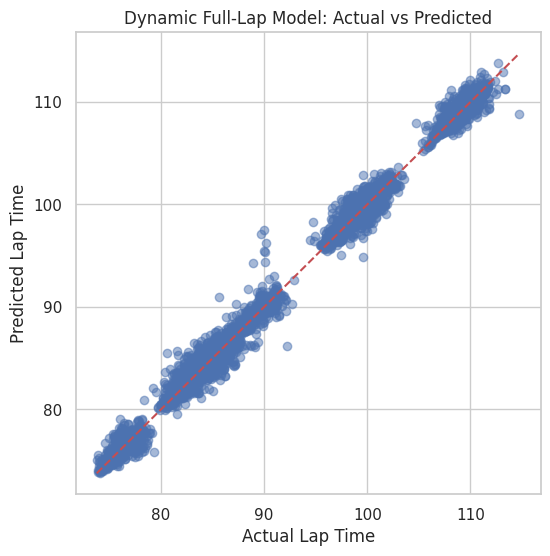

In [114]:
# Cell 30 — Dynamic full-lap actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test_dynamic, pred_test_dynamic, alpha=0.5)

min_val = min(y_test_dynamic.min(), pred_test_dynamic.min())
max_val = max(y_test_dynamic.max(), pred_test_dynamic.max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Dynamic Full-Lap Model: Actual vs Predicted")
plt.show()

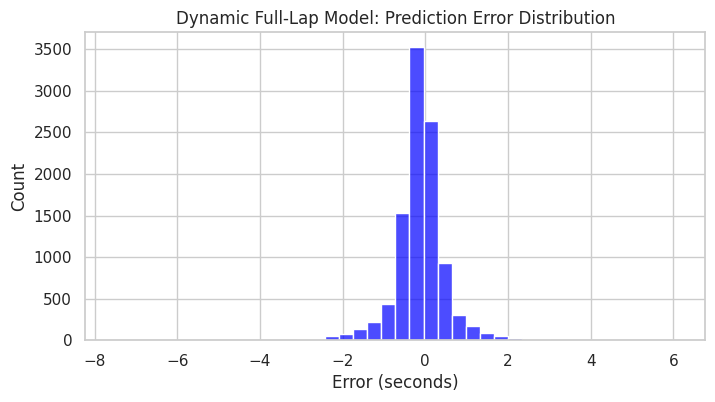

In [115]:
# Cell 31 — Dynamic full-lap error distribution
errors_dynamic = y_test_dynamic - pred_test_dynamic

plt.figure(figsize=(8,4))
sns.histplot(errors_dynamic, bins=40, color="blue", alpha=0.7)
plt.title("Dynamic Full-Lap Model: Prediction Error Distribution")
plt.xlabel("Error (seconds)")
plt.show()

In [116]:
# Cell 32 — SHAP sample for dynamic full-lap model
MAX_SHAP_ROWS = 1000

if len(X_test_dynamic) > MAX_SHAP_ROWS:
    X_shap = X_test_dynamic.sample(MAX_SHAP_ROWS, random_state=42)
else:
    X_shap = X_test_dynamic.copy()

print("Rows used for SHAP:", X_shap.shape[0])

Rows used for SHAP: 1000


In [117]:
# Cell 33 — Build SHAP explainer
X_train_shap = X_train_dynamic_all.astype(float)
X_shap_input = X_shap.astype(float)

if best_dynamic_model_name == "Ridge":
    ridge_model = best_dynamic_model.named_steps["ridge"]
    scaler = best_dynamic_model.named_steps["standardscaler"]

    X_train_scaled = scaler.transform(X_train_shap)
    X_shap_scaled = scaler.transform(X_shap_input)

    explainer = shap.LinearExplainer(ridge_model, X_train_scaled)
    shap_values = explainer(X_shap_scaled)
else:
    explainer = shap.Explainer(best_dynamic_model)
    shap_values = explainer(X_shap_input)

print("SHAP explainer ready for:", best_dynamic_model_name)

SHAP explainer ready for: Ridge


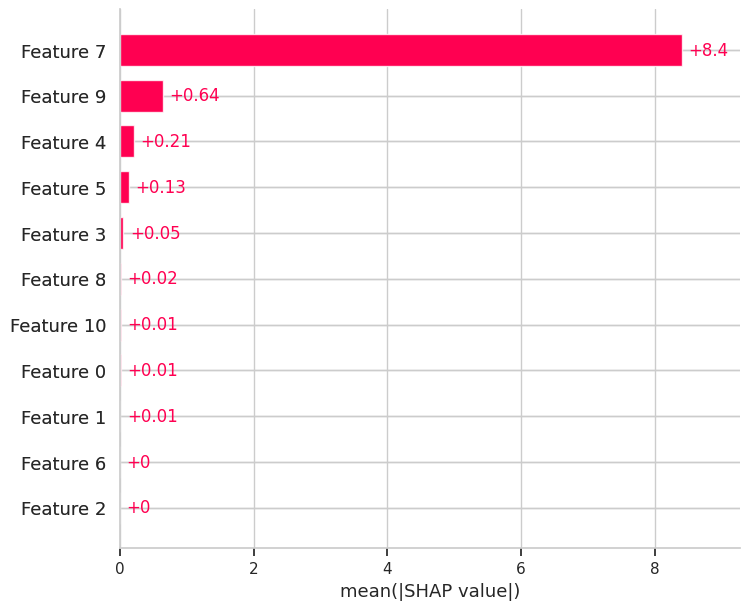

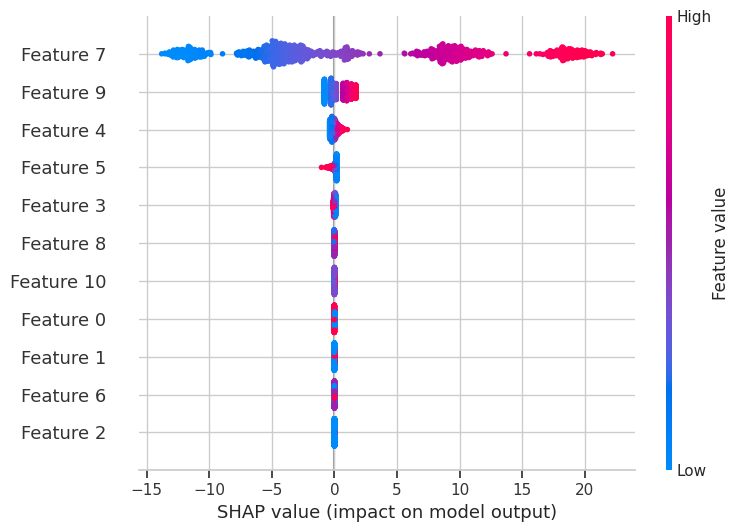

In [118]:
# Cell 34 — SHAP global plots
shap.plots.bar(shap_values, max_display=15)
plt.show()

shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

Representative index: 3590
Absolute error: 0.25479496066363083


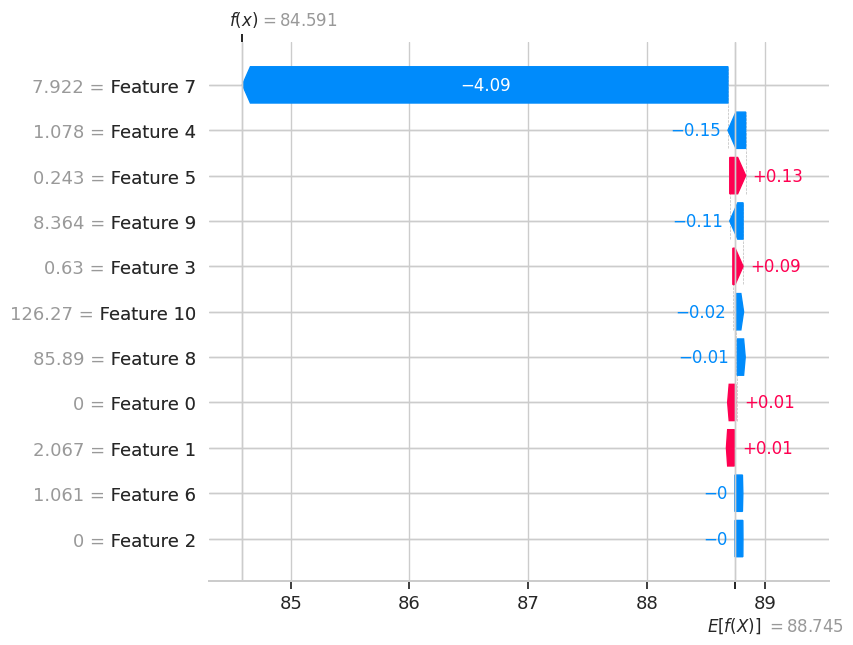

Actual LapTimeSeconds: 84.846
Predicted LapTimeSeconds: 84.59120503933637


In [119]:
# Cell 35 — SHAP waterfall plot for one representative case
y_shap_true = y_test_dynamic.loc[X_shap.index]
y_shap_pred = pd.Series(best_dynamic_model.predict(X_shap_input), index=X_shap.index)

abs_errors = (y_shap_true - y_shap_pred).abs()
median_abs_error = abs_errors.median()
representative_index = (abs_errors - median_abs_error).abs().idxmin()
example_idx = X_shap.index.get_loc(representative_index)

print("Representative index:", representative_index)
print("Absolute error:", float(abs_errors.loc[representative_index]))

shap.plots.waterfall(shap_values[example_idx], max_display=15)
plt.show()

print("Actual LapTimeSeconds:", float(y_shap_true.loc[representative_index]))
print("Predicted LapTimeSeconds:", float(y_shap_pred.loc[representative_index]))

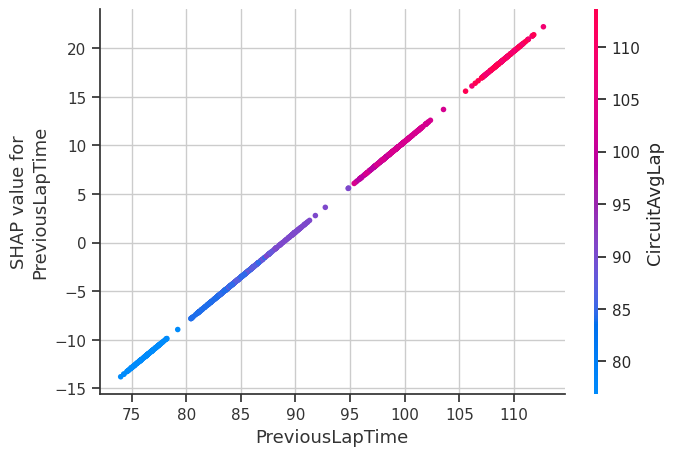

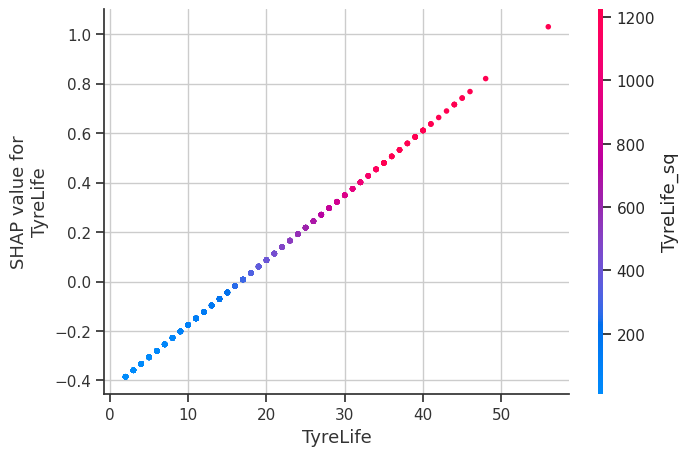

In [120]:
# Cell 36 — SHAP dependence plots
sv = shap_values.values

for feature in ["PreviousLapTime", "TyreLife"]:
    if feature in X_shap_input.columns:
        shap.dependence_plot(feature, sv, X_shap_input, interaction_index="auto")
        plt.show()

Representative LIME case
Index: 3590
Actual: 84.846
Predicted: 84.591
Error: 0.255

Top LIME features:
PreviousLapTime: 9.9139
CircuitAvgLap: 0.7094
TyreLife: 0.2673
TyreLife_sq: -0.1933
LapNumber: -0.0626
DriverAvgLap: 0.0202
TeamAvgLap: 0.0158
Compound_HARD: -0.0123
Compound_MEDIUM: 0.0086
Stint: 0.0026


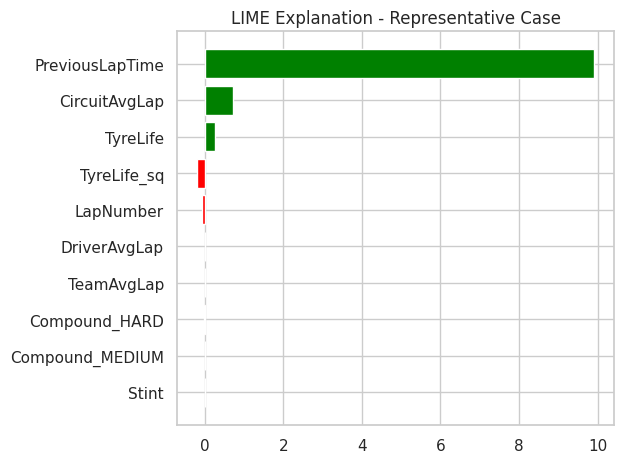

In [121]:
# Cell 37 — Representative LIME explanation
lime_explainer = LimeTabularExplainer(
    training_data=X_train_shap.values,
    feature_names=X_train_shap.columns.tolist(),
    mode="regression",
    discretize_continuous=False,
    random_state=42
)

exp = lime_explainer.explain_instance(
    data_row=X_shap_input.iloc[example_idx].values,
    predict_fn=best_dynamic_model.predict,
    num_features=10
)

actual = float(y_shap_true.loc[representative_index])
predicted = float(y_shap_pred.loc[representative_index])
error = actual - predicted

print("Representative LIME case")
print("Index:", representative_index)
print("Actual:", round(actual, 3))
print("Predicted:", round(predicted, 3))
print("Error:", round(error, 3))
print("\nTop LIME features:")

lime_rows = []
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")
    lime_rows.append({
        "Index": representative_index,
        "Actual": actual,
        "Predicted": predicted,
        "Error": error,
        "Feature": feature,
        "Weight": weight
    })

lime_results_df = pd.DataFrame(lime_rows)

fig = exp.as_pyplot_figure()
plt.title("LIME Explanation - Representative Case")
plt.tight_layout()
plt.show()

In [122]:
# Cell 38 — Save main outputs
saved_files = []

def save_and_log(path, save_type="file", obj=None):
    if save_type == "csv":
        obj.to_csv(path, index=False)
    elif save_type == "json":
        with open(path, "w") as f:
            json.dump(obj, f, indent=4)
    elif save_type == "joblib":
        joblib.dump(obj, path)
    saved_files.append(path)

# Save cleaned dataset
cleaned_data_path = os.path.join(PROCESSED_DIR, "cleaned_laps_dataset.parquet")
df.to_parquet(cleaned_data_path, index=False)
saved_files.append(cleaned_data_path)

# Save event schedule
schedule_path = os.path.join(PROCESSED_DIR, "event_schedule_used.csv")
schedule_df.to_csv(schedule_path, index=False)
saved_files.append(schedule_path)

# Save validation results
save_and_log(os.path.join(RESULTS_DIR, "static_validation_results.csv"), "csv", static_val_results_df)
save_and_log(os.path.join(RESULTS_DIR, "dynamic_validation_results.csv"), "csv", dynamic_val_results_df)

# Save final test results
save_and_log(os.path.join(RESULTS_DIR, "static_test_results.json"), "json", test_results_static)
save_and_log(os.path.join(RESULTS_DIR, "dynamic_test_results.json"), "json", test_results_dynamic)

# Save dynamic test predictions
dynamic_preds_df = pd.DataFrame({
    "Actual": y_test_dynamic.values,
    "Predicted": pred_test_dynamic
})
save_and_log(os.path.join(RESULTS_DIR, "dynamic_test_predictions.csv"), "csv", dynamic_preds_df)

# Save models
save_and_log(os.path.join(MODEL_DIR, "best_static_model.pkl"), "joblib", best_static_model)
save_and_log(os.path.join(MODEL_DIR, "best_dynamic_model.pkl"), "joblib", best_dynamic_model)

# Save SHAP sample
shap_sample_path = os.path.join(RESULTS_DIR, "dynamic_shap_sample.csv")
X_shap.to_csv(shap_sample_path, index=True)
saved_files.append(shap_sample_path)

# Save LIME table
save_and_log(os.path.join(RESULTS_DIR, "lime_representative_case.csv"), "csv", lime_results_df)

print("Saved files:")
for file_path in saved_files:
    print("-", file_path)

Saved files:
- /content/drive/MyDrive/Fast_F1_PROJECT21/data/processed/cleaned_laps_dataset.parquet
- /content/drive/MyDrive/Fast_F1_PROJECT21/data/processed/event_schedule_used.csv
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/static_validation_results.csv
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/dynamic_validation_results.csv
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/static_test_results.json
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/dynamic_test_results.json
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/dynamic_test_predictions.csv
- /content/drive/MyDrive/Fast_F1_PROJECT21/models/best_static_model.pkl
- /content/drive/MyDrive/Fast_F1_PROJECT21/models/best_dynamic_model.pkl
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/dynamic_shap_sample.csv
- /content/drive/MyDrive/Fast_F1_PROJECT21/results/lime_representative_case.csv
